In [1]:
import pandas as pd
import numpy as np

# data loading

In [2]:
df=pd.read_csv("hand_landmarks_data.csv")

In [24]:
df.head().T

,0,1,2,3,4
x1,262.669968,83.351778,187.756977,114.976696,188.795288
y1,257.304901,346.059113,260.235492,331.594238,141.727867
z1,-0.0,-0.0,-0.0,-0.0,-0.0
x2,257.417542,81.925037,195.460579,114.503494,188.520905
y2,247.109055,328.562347,241.506035,320.549957,127.947464
...,...,...,...,...,...
z20,-0.024577,-0.037336,-0.040469,-0.027863,-0.024087
x21,208.006393,152.431698,272.989952,155.990364,241.587769
y21,259.608673,343.015991,272.272231,329.548828,128.477188
z21,-0.026722,-0.036136,-0.038301,-0.027723,-0.023486


In [25]:
df['label'].unique()

<StringArray>
[           'call',         'dislike',            'fist',            'four',
            'like',            'mute',              'ok',             'one',
            'palm',           'peace',  'peace_inverted',            'rock',
            'stop',   'stop_inverted',           'three',          'three2',
          'two_up', 'two_up_inverted']
Length: 18, dtype: str

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22  y8      2

# Data Visualization

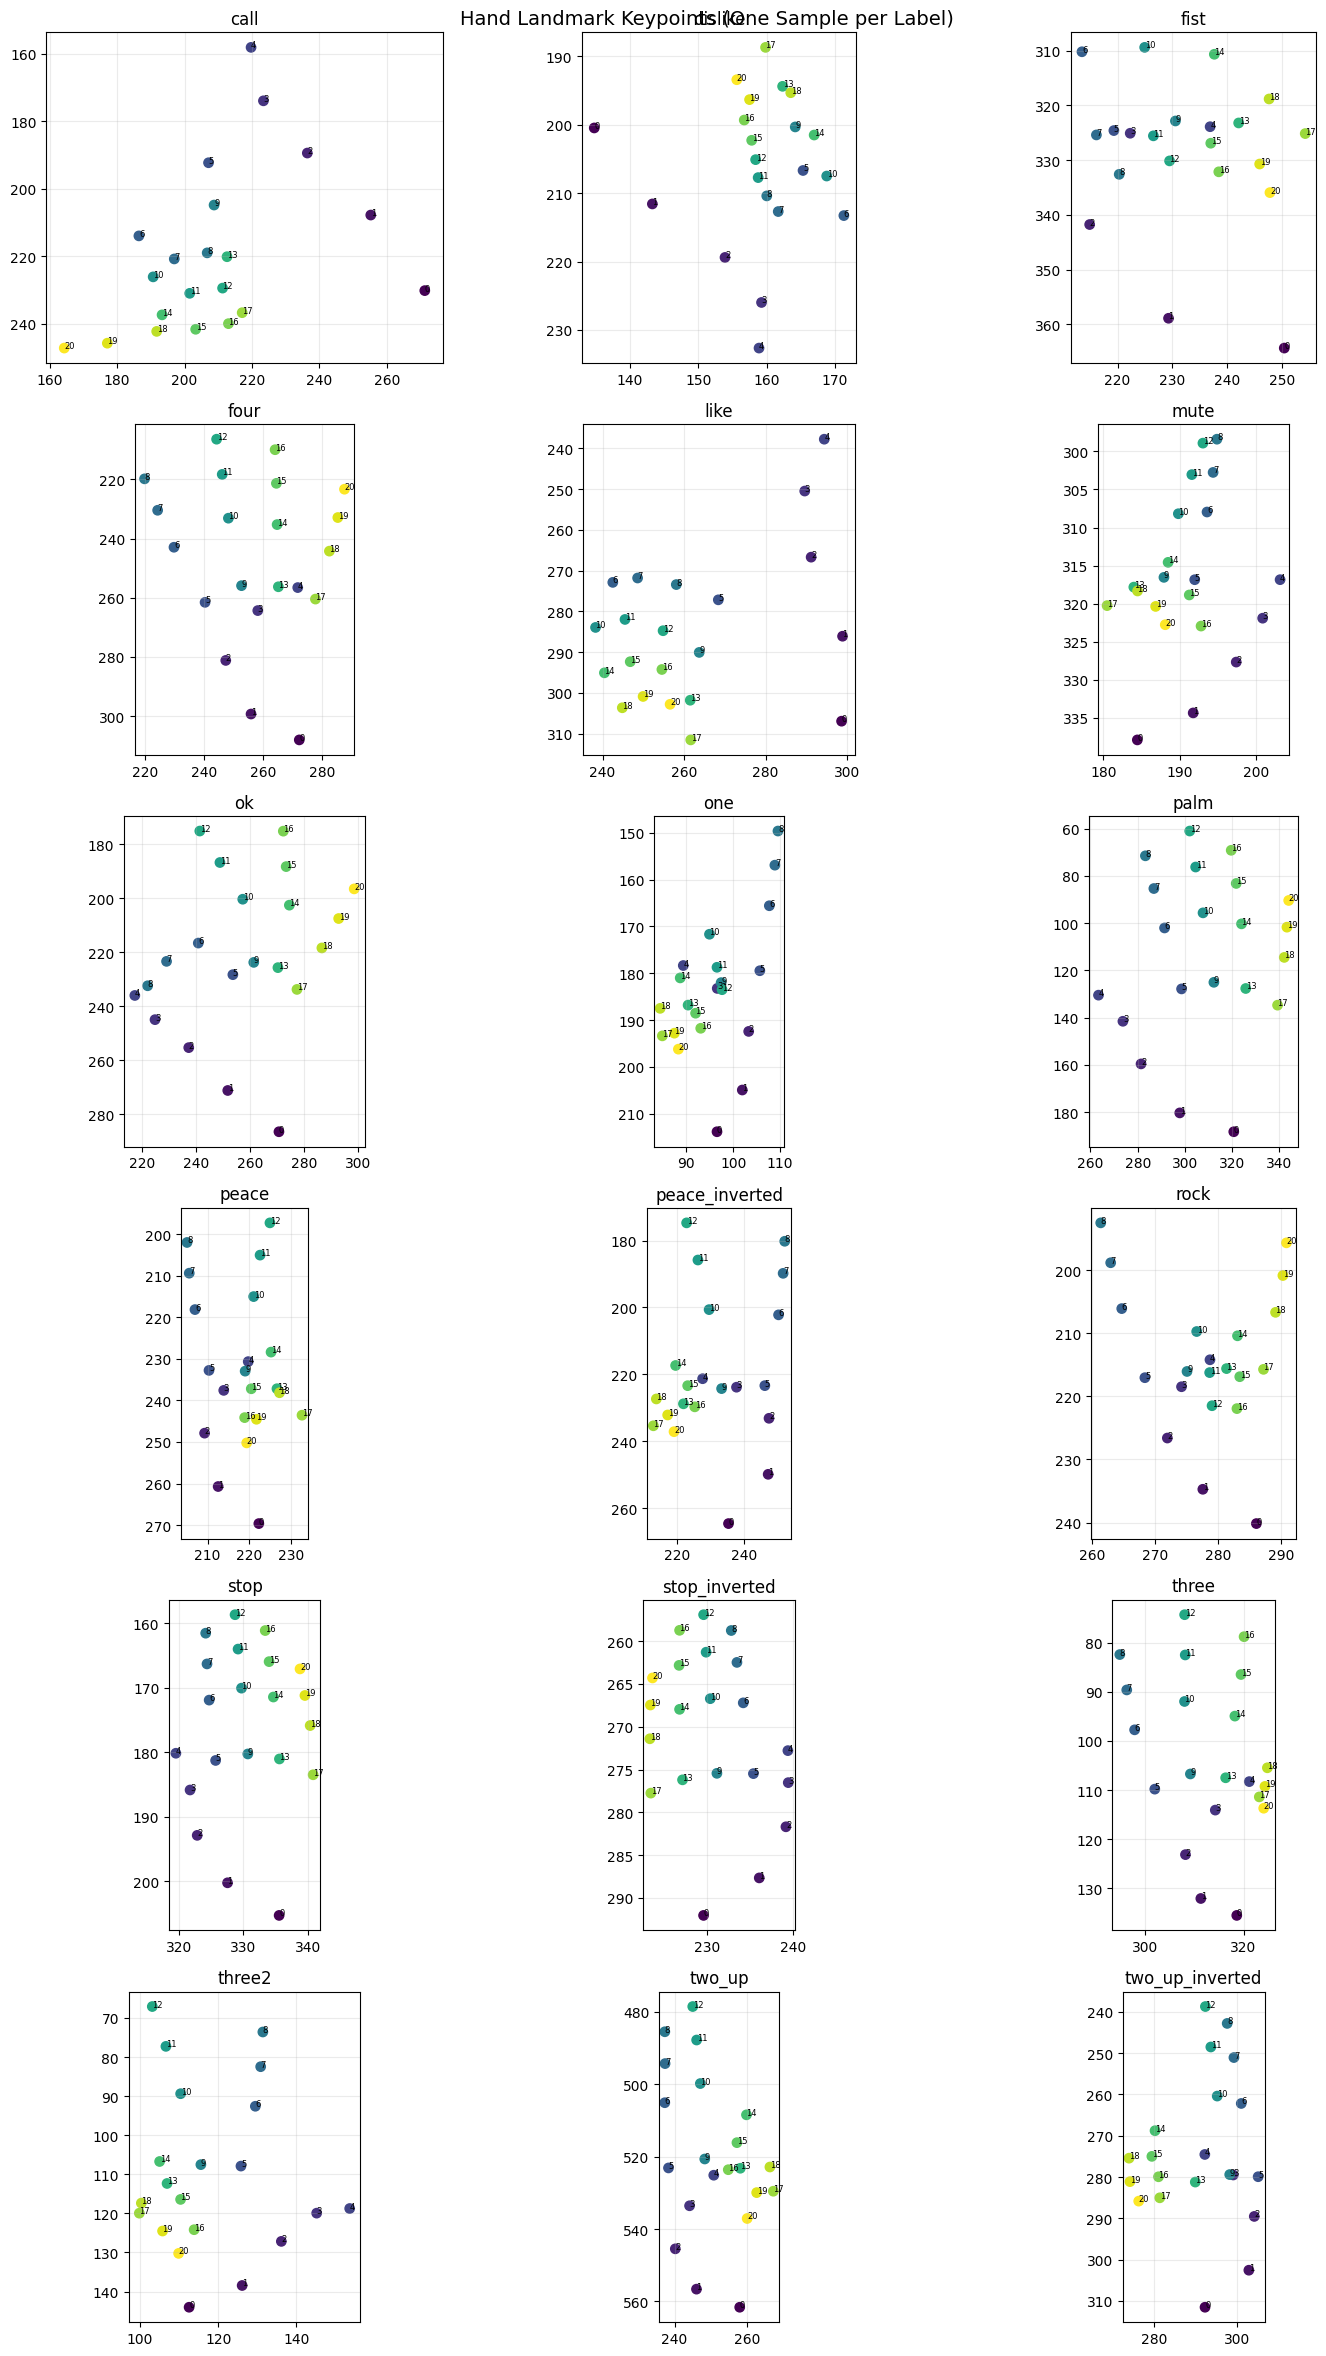

In [27]:
import matplotlib.pyplot as plt
import re
import math

# Detect x/y landmark columns (supports names like x0, x_0, y0, y_0)
def _sorted_landmark_cols(cols, axis_prefix):
    matched = [c for c in cols if re.match(rf"^{axis_prefix}_?\d+$", c, flags=re.IGNORECASE)]
    return sorted(matched, key=lambda c: int(re.findall(r"\d+", c)[0]))

x_cols = _sorted_landmark_cols(df.columns, "x")
y_cols = _sorted_landmark_cols(df.columns, "y")

# Fallback if columns are stored as repeating x,y,z triplets without x*/y* names
if not x_cols or not y_cols:
    feature_cols = [c for c in df.columns if c != "label"]
    if len(feature_cols) % 3 == 0:
        x_cols = feature_cols[0::3]
        y_cols = feature_cols[1::3]

if not x_cols or not y_cols:
    raise ValueError("Could not infer x/y landmark columns from the dataset.")

if "label" not in df.columns:
    raise ValueError("Column 'label' is required for one-sample-per-label visualization.")

# Pick exactly one sample per label (keeps the label column intact)
sample_df = df.groupby("label", as_index=False).sample(n=1, random_state=42).reset_index(drop=True)

n_labels = len(sample_df)
n_cols = min(3, n_labels)
n_rows = math.ceil(n_labels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    x = row[x_cols].astype(float).to_numpy()
    y = row[y_cols].astype(float).to_numpy()

    ax.scatter(x, y, s=45, c=range(len(x)), cmap="viridis")

    # Label each keypoint index to make landmark positions easy to inspect
    for i, (xi, yi) in enumerate(zip(x, y)):
        ax.text(xi, yi, str(i), fontsize=6)

    ax.set_title(str(row["label"]))
    ax.set_aspect("equal")
    ax.invert_yaxis()  # image-style orientation
    ax.grid(alpha=0.25)

# Hide any unused axes
for j in range(n_labels, len(axes)):
    axes[j].axis("off")

plt.suptitle("Hand Landmark Keypoints (One Sample per Label)", fontsize=14)
plt.tight_layout()
plt.show()

#  Data Preprocessing:


In [3]:
# Data preprocessing for model training
# 1) clean data, 2) handle missing values, 3) train/test split, 4) normalize features

RANDOM_STATE = 42
TEST_SIZE = 0.2
LABEL_COL = "label"


# Keep a working copy
proc_df = df.copy()

# Separate feature columns from target
feature_cols = [c for c in proc_df.columns if c != LABEL_COL]

# Convert all features to numeric and coerce invalid values to NaN
proc_df[feature_cols] = proc_df[feature_cols].apply(pd.to_numeric, errors="coerce")

# Basic cleaning
before_rows = len(proc_df)
proc_df = proc_df.drop_duplicates().reset_index(drop=True)
after_rows = len(proc_df)

# Missing value handling: fill feature NaNs with feature-wise median
missing_before = proc_df[feature_cols].isna().sum().sum()
feature_medians = proc_df[feature_cols].median()
proc_df[feature_cols] = proc_df[feature_cols].fillna(feature_medians)
missing_after = proc_df[feature_cols].isna().sum().sum()

# If any label is missing, drop those rows
proc_df = proc_df.dropna(subset=[LABEL_COL]).reset_index(drop=True)

# Build X/y
X = proc_df[feature_cols].copy()
y = proc_df[LABEL_COL].copy()

# Optional numeric encoding for classification models
label_to_id = {label: i for i, label in enumerate(sorted(y.unique()))}
y_encoded = y.map(label_to_id)

# Stratified train/test split without sklearn dependency
rng = np.random.default_rng(RANDOM_STATE)
train_idx = []
test_idx = []

for label, group in proc_df.groupby(LABEL_COL):
    indices = group.index.to_numpy().copy()
    rng.shuffle(indices)

    n_test = max(1, int(round(len(indices) * TEST_SIZE)))
    n_test = min(n_test, len(indices) - 1) if len(indices) > 1 else 1

    test_idx.extend(indices[:n_test])
    train_idx.extend(indices[n_test:])

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train = X.loc[train_idx].reset_index(drop=True)
X_test = X.loc[test_idx].reset_index(drop=True)
y_train = y.loc[train_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)
y_train_encoded = y_encoded.loc[train_idx].reset_index(drop=True)
y_test_encoded = y_encoded.loc[test_idx].reset_index(drop=True)

# Normalize with train-set statistics only (prevents data leakage)
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1.0)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("Preprocessing complete")
print(f"Rows before/after duplicate removal: {before_rows}/{after_rows}")
print(f"Missing feature values before/after fill: {int(missing_before)}/{int(missing_after)}")
print(f"Train shape: {X_train_norm.shape}, Test shape: {X_test_norm.shape}")
print(f"Number of classes: {len(label_to_id)}")
print("Label mapping:", label_to_id)

# Final training-ready objects:
# X_train_norm, X_test_norm, y_train_encoded, y_test_encoded


Preprocessing complete
Rows before/after duplicate removal: 25675/25675
Missing feature values before/after fill: 0/0
Train shape: (20541, 63), Test shape: (5134, 63)
Number of classes: 18
Label mapping: {'call': 0, 'dislike': 1, 'fist': 2, 'four': 3, 'like': 4, 'mute': 5, 'ok': 6, 'one': 7, 'palm': 8, 'peace': 9, 'peace_inverted': 10, 'rock': 11, 'stop': 12, 'stop_inverted': 13, 'three': 14, 'three2': 15, 'two_up': 16, 'two_up_inverted': 17}


# Model Training

In [4]:
from time import perf_counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Ensure preprocessing cell has been executed
required_vars = ["X_train_norm", "X_test_norm", "y_train", "y_test"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Run the preprocessing cell first. Missing variables: {missing_vars}"
    )

# Train and compare at least 3 models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel="rbf", C=5, gamma="scale", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

results = []
trained_models = {}

for model_name, model in models.items():
    t0 = perf_counter()
    model.fit(X_train_norm, y_train)
    train_time = perf_counter() - t0

    y_pred = model.predict(X_test_norm)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    results.append(
        {
            "Model": model_name,
            "Accuracy": acc,
            "Macro F1": f1,
            "Train Time (s)": train_time,
        }
    )
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values(by=["Accuracy", "Macro F1"], ascending=False)
print("Model comparison:")
display(results_df.reset_index(drop=True))

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_best_pred = best_model.predict(X_test_norm)

print(f"Best model: {best_model_name}")
print("\nClassification report (best model):")
print(classification_report(y_test, y_best_pred))


Model comparison:


,Model,Accuracy,Macro F1,Train Time (s)
0,SVM (RBF),0.931437,0.933006,20.396962
1,Random Forest,0.845734,0.847363,28.018616
2,KNN,0.669653,0.678697,0.065089


Best model: SVM (RBF)

Classification report (best model):
                 precision    recall  f1-score   support

           call       0.97      0.96      0.96       301
        dislike       1.00      0.99      0.99       259
           fist       0.98      0.99      0.98       189
           four       0.88      0.93      0.90       327
           like       0.96      0.97      0.97       287
           mute       0.97      0.95      0.96       217
             ok       1.00      0.97      0.99       318
            one       0.98      0.97      0.98       253
           palm       0.93      0.90      0.92       330
          peace       0.80      0.87      0.83       288
 peace_inverted       0.87      0.80      0.83       299
           rock       0.99      1.00      0.99       292
           stop       0.88      0.94      0.91       296
  stop_inverted       0.98      0.99      0.98       313
          three       0.99      0.94      0.96       291
         three2       0.97  